# H-Reflex Post-Hoc Analysis

Loads paired `.hrs1` / `.hrs2` recording files from the H-Reflex App and runs the full post-hoc pipeline:

| Section | What it does |
|---|---|
| 1 – Setup | Import all helpers |
| 2 – Recording Files | Point to your session folder |
| 3 – Read Data Files | Load HRS1 + HRS2 and print summaries |
| 4 – Analysis Configuration | Set M/H windows and view parameters |
| 5 – Data Overview | Amplitude histogram + trial timeline |
| 6 – Trial Quality Filter | Remove failed ADC-sync trials |
| 7 – Waveform Analysis | Grand-averaged waveforms + recruitment curve |
| 8 – Individual Trial Viewer | Interactive per-trial grid |
| 9 – Background EMG | Per-trial pre-stim background distribution |
| 10 – EMG Activity Bins | Bin trials by background EMG level |
| 11 – Bin Overview | Averaged waveforms + M/H/H:M bars per bin |
| 12 – Per-Bin Viewer | Full analysis for a single selected bin |
| 13 – Bin Statistics | Numeric M-MRA / H-MRA / H:M table |
| 14 – H:M Ratio Summary | Box plot + histogram by polarity group |
| 15 – SNR Analysis (RMS) | RMS signal-to-noise per amplitude |
| 16 – SNR Analysis (MRA) | Mean-rectified SNR per amplitude |

# Section 1: Setup

Import all analysis utilities from `helpers.py`.

In [18]:
import os
import numpy as np
from helpers import (
    read_hrs1, read_hrs2, find_hrs_files,
    print_hrs1_summary, print_hrs2_summary,
    plot_amplitude_distribution, plot_actual_trial_timeline,
    filter_failed_trials,
    plot_hrs2_analysis, plot_hrs2_trials,
    plot_background_grand_means,
    compute_trial_bins, filter_trials, compute_equal_bin_ranges,
    build_merged_amp_groups,
    plot_bin_overview, create_bin_viewer, print_bin_statistics,
    split_trials_by_polarity, plot_hm_ratio_summary,
    compute_snr_analysis, compute_mra_snr_analysis,
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Recording Files

Set `recording_dir` to the folder containing your `.hrs1` and `.hrs2` files.  
Set `recording_sample_rate` to override the sample rate; `None` auto-detects it from the HRS1 header.

In [19]:
recording_dir         = "HRPilot-18/C2_HRPILOT-18_BOOTH1_500US_6-16-26"
recording_sample_rate = 15000  # set to e.g. 5000 or 10000 to override; None = auto-detect

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1: {os.path.basename(hrs1_path)}")
print(f"  HRS2: {os.path.basename(hrs2_path) if hrs2_path else 'not found — HRS2 sections will be skipped'}")

Recording directory: HRPilot-18/C2_HRPILOT-18_BOOTH1_500US_6-16-26
  HRS1: C2_HRPILOT-18_BOOTH1_500US_6-16-26_20260616T134641.hrs1
  HRS2: C2_HRPILOT-18_BOOTH1_500US_6-16-26_20260616T135834.hrs2


# Section 3: Read Data Files

Load the HRS1 (EMG Characterization) and HRS2 (MH Recruitment Curve) binary files and print their summaries.

In [20]:
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

if hrs2_path is None:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
    print("No HRS2 file — HRS2 sections will be skipped.")
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS1 Header ===
  File:               C2_HRPILOT-18_BOOTH1_500US_6-16-26_20260616T134641.hrs1
  File version:       1
  Subject ID:         C2_HRPILOT-18_BOOTH1_500US_6-16-26
  Session datetime:   2026-06-16 13:46:41.510068
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        15000.0 Hz
  Trials/hr data: centre=440.99 µV, elapsed=0.017 h, 20 window sizes

  Trials found:       8
  EMG data blocks:    4824

=== First Trial ===
  End datetime:       2026-06-16 13:47:24.471140
  Start index:        0
  Grand mean:         510.4590
  Bins count:         46
  Monitored signal N: 34500

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 192 samples
  Diff samples:       192
  Filtered samples:   192
  Abs samp

# Section 4: Analysis Configuration

Set the M-wave and H-wave detection windows and viewing parameters used by all downstream sections.  
**Change these here** — every subsequent section picks them up automatically.

In [21]:
# Viewing windows (ms relative to stim onset)
PRE_PLOT_MS  = 5
POST_PLOT_MS = 25
PRE_AVG_MS   = 5
POST_AVG_MS  = 25
N_PER_PAGE   = 6

# M/H wave detection windows (ms relative to stim onset)
M_WAVE_START_MS =  1.8
M_WAVE_END_MS   =  4.5
H_WAVE_START_MS =  7
H_WAVE_END_MS   = 12

print(f"M-wave window : {M_WAVE_START_MS} – {M_WAVE_END_MS} ms")
print(f"H-wave window : {H_WAVE_START_MS} – {H_WAVE_END_MS} ms")
print(f"Plot window   : -{PRE_PLOT_MS} to +{POST_PLOT_MS} ms  |  Avg window: -{PRE_AVG_MS} to +{POST_AVG_MS} ms")

M-wave window : 1.8 – 4.5 ms
H-wave window : 7 – 12 ms
Plot window   : -5 to +25 ms  |  Avg window: -5 to +25 ms


# Section 5: Data Overview

Histogram of stimulation amplitudes delivered across the session and the actual inter-trial interval (ITI) timeline.

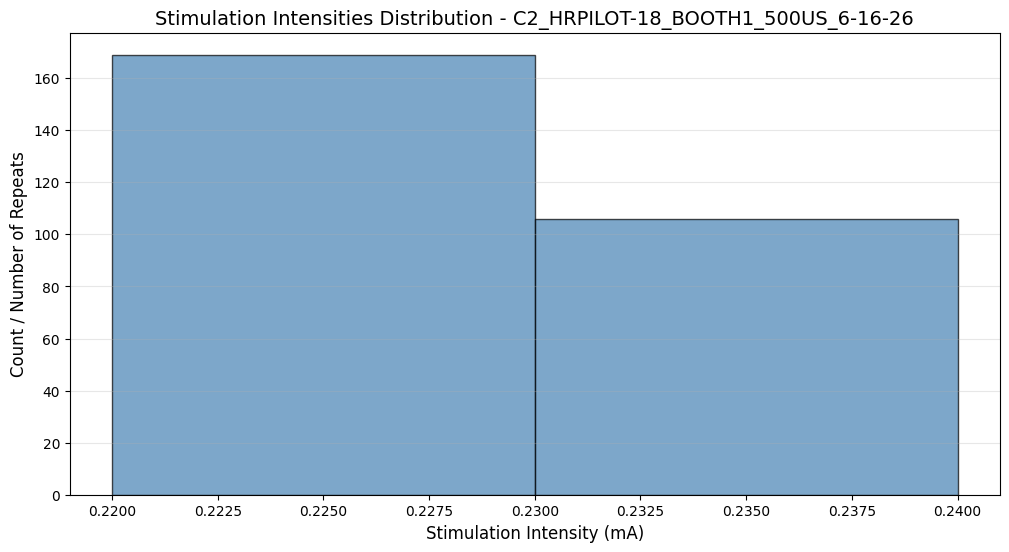

Actual trial timeline (275 trials)
  Recording span : 9514.9 s  (2.643 h)
  Trial rate     : 104.0 trials / hour
  ITI — mean: 34726 ms  |  median: 7078 ms  |  min: 5193 ms  |  max: 468045 ms


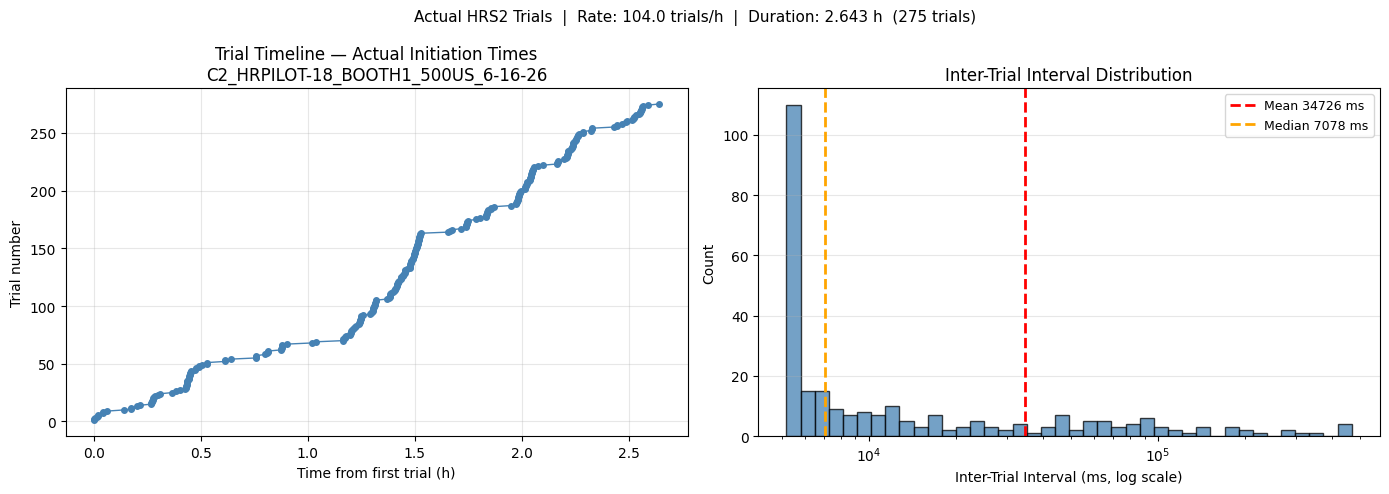

In [22]:
plot_amplitude_distribution(hrs2_trials, hrs2_header)
plot_actual_trial_timeline(hrs2_trials, header=hrs2_header)

# Section 6: Trial Quality Filter

Automatically detect and remove trials where the ADC sync pulse was missed or the stim onset could not be verified.  
The cleaned trial list replaces `hrs2_trials` for all downstream sections.

In [23]:
hrs2_trials = filter_failed_trials(
    hrs2_trials, hrs2_header, hrs2_emg_blocks,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

File version : 7  (pre-computed fields used)
Total trials : 275
Passed       : 275
Failed       : 0

No failed trials — all trials passed ADC-sync check.
Failed trials removed : 0
Trials remaining      : 275


# Section 7: Waveform Analysis

Grand-averaged EMG waveforms and recruitment curve across all stimulation amplitudes.  
A polarity toggle appears automatically for dual-polarity sessions.

In [24]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# Pool multiple stimulation intensities into one merged group.
# MERGED_GROUPS is a list of lists, e.g.:
#   [[0.12, 0.13], [0.15, 0.16, 0.17]]  →  two merged groups
# Leave as [] to use the default (unmerged) grouping.
MERGED_GROUPS = []

if MERGED_GROUPS:
    _hrs2_trials_plot = build_merged_amp_groups(hrs2_trials, MERGED_GROUPS)
else:
    _hrs2_trials_plot = hrs2_trials


In [ ]:
plot_hrs2_analysis(
    _hrs2_trials_plot, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 2 amplitude groups across 1 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

# Section 8: Individual Trial Viewer

Interactive per-trial grid with page navigation and zoom.  
Use the signal overlays to inspect the ADC sync pulse and stimulator output for each trial.  
Double-click a subplot to zoom in; use the dropdown and **View trial** button to navigate.

In [26]:
plot_hrs2_trials(
    _hrs2_trials_plot, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    emg_blocks=hrs2_emg_blocks,
)

Loaded 275 trials across 46 page(s).
Sample rate: 15000 Hz  |  ms/sample: 0.0667
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 9: Background EMG Distribution

Extract each trial's pre-stimulus background EMG grand mean and plot the distribution.  
For HRS2 v5+ files this uses the value stored directly in each trial; older files reconstruct it from the EMG blocks.  
The returned `state` dict (key `'trial_bg_gm'`) is passed to Section 10 for binning.

Trials: 275  (stored: 275, reconstructed: 0)
Background  Min=343.39  Q1=384.43  Median=400.52  Q3=422.46  Max=462.53 µV


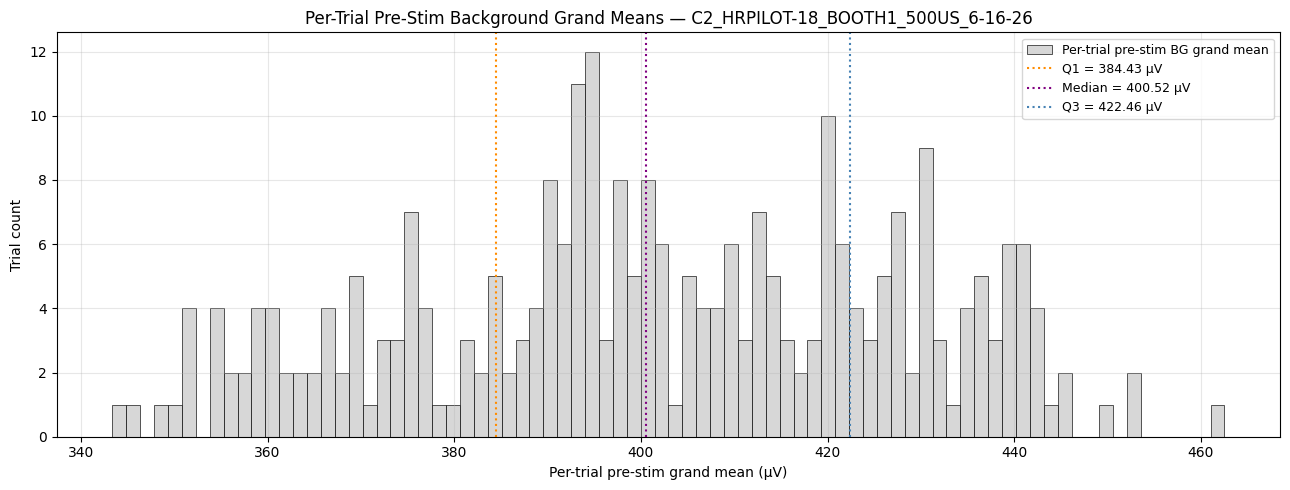

In [27]:
state = plot_background_grand_means(
    hrs2_trials, hrs2_emg_blocks, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 10: EMG Activity Bins

**Optional subset filter** — restrict the analysis to a specific polarity and/or stimulation intensity
range. Set `FILTER_POLARITY` and/or `FILTER_INTENSITIES`, or leave both as `None` to include all trials.

**Bin definition** — set `BIN_RANGES = 'auto'` to automatically compute equal-count bin boundaries
from the filtered trial set, controlled by `N_BINS`. Or set `BIN_RANGES` to a list of manual `(lo, hi)` pairs.

`BIN_MODE` controls what metric is used for binning:
- `'EMG'` — pre-stim background grand mean (default)
- `'M_WAVE'` — M-wave MRA
- `'H_WAVE'` — H-wave MRA

In [28]:
# ── Subset filter (optional) ──────────────────────────────────────────
# FILTER_POLARITY  : 'normal' | 'reversed' | None  (None = all trials)
# FILTER_POLARITY = None
FILTER_POLARITY = None

# FILTER_INTENSITIES: None (all) | tuple (lo, hi) in mA | list of exact mA values
#   e.g.  (0.5, 2.0)   keeps trials with amplitude in [0.5, 2.0] mA
#   e.g.  [1.0, 1.5]   keeps only those exact amplitudes (±0.001 mA tolerance)
# FILTER_INTENSITIES = None

FILTER_INTENSITIES = None


#FILTER_POLARITY    = None    # 'normal' | 'reversed' | None
#FILTER_INTENSITIES = None    # (lo, hi) mA | [list of mA] | None
# ───────────────────────────────────────────────────────────────────────

# ── Bin definition ──────────────────────────────────────────────────────
BIN_MODE   = 'EMG' # can also do "H-Wave", "M-Wave", "H:M"
N_BINS     = 3       # bins to create when BIN_RANGES = 'auto'
BIN_RANGES = 'auto'  # 'auto' → equal-count | [(lo, hi), ...] → manual
#BIN_RANGES = [(50, 110), (110, 140), (140, 1000)]  # µV ranges
# ───────────────────────────────────────────────────────────────────────

analysis_trials, analysis_state = filter_trials(
    hrs2_trials, state,
    filter_polarity=FILTER_POLARITY,
    filter_intensities=FILTER_INTENSITIES,
)

if BIN_RANGES == 'auto':
    BIN_RANGES = compute_equal_bin_ranges(
        analysis_trials, BIN_MODE, N_BINS, analysis_state,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    )

binned_trials, bin_labels, bin_colors, trial_bg_dict, bin_unit, pol_labels, _ = compute_trial_bins(
    analysis_trials,
    bin_mode=BIN_MODE,
    bin_ranges=BIN_RANGES,
    state=analysis_state,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

No filter applied — using all 275 trials
Auto-bin: 3 equal-count bins  |  275 trials  |  µV bg
  Bin 1: [343.39, 391.73)  →  91 trials
  Bin 2: [391.73, 415.31)  →  91 trials
  Bin 3: [415.31, 462.54)  →  92 trials
Single-polarity session (config 1 only): 275 reversed trials.
BIN_MODE = 'EMG'  |  Unit: µV bg
Bin                             Reversed (1)
--------------------------------------------
Bin 1: 343.39–391.73 µV bg  [c=367.6, Δ48.34]  91          
Bin 2: 391.73–415.31 µV bg  [c=403.5, Δ23.58]  91          
Bin 3: 415.31–462.54 µV bg  [c=438.9, Δ47.23]  92          


# Section 11: Bin Overview

Averaged EMG waveforms for each bin overlaid on the same axes, plus M-wave MRA, H-wave MRA, and H:M ratio bar charts with mean ± SD.  
A polarity toggle appears automatically for dual-polarity sessions.

In [29]:
plot_bin_overview(
    binned_trials, bin_labels, bin_colors, pol_labels, hrs2_header,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bin_ranges=BIN_RANGES, bin_unit=bin_unit,
)

# Section 12: Per-Bin Viewer

Select a polarity and bin, then click **Load bin viewer** to inspect that trial subset in detail:  
background EMG distribution, averaged waveforms + recruitment curve, and individual trial grid.

In [30]:
create_bin_viewer(
    binned_trials, bin_labels, bin_colors, pol_labels,
    hrs2_header, hrs2_emg_blocks, trial_bg_dict,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    pre_avg_ms=PRE_AVG_MS,   post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

# Section 13: Bin Statistics

Per-bin × per-polarity numeric table: trial count, mean M-wave MRA, mean H-wave MRA, and mean H:M ratio.

In [31]:
print_bin_statistics(
    binned_trials, bin_labels, pol_labels,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
)

Polarity              Bin                                         n    M-MRA µV    H-MRA µV       H:M
-----------------------------------------------------------------------------------------------------
Reversed (1)          Bin 1: 343.39–391.73 µV bg  [c=367.6, Δ48.34]     91      2006.8       391.9     0.199
Reversed (1)          Bin 2: 391.73–415.31 µV bg  [c=403.5, Δ23.58]     91      1951.0       474.2     0.250
Reversed (1)          Bin 3: 415.31–462.54 µV bg  [c=438.9, Δ47.23]     92      1922.6       444.9     0.236



# Section 14: H:M Ratio Summary

Box plot and histogram of the H:M ratio split by stimulation polarity group.  
Shows distribution shape, SD, CV, and 20th/80th percentiles.

Single-polarity session (config 1 only): 275 reversed trials.


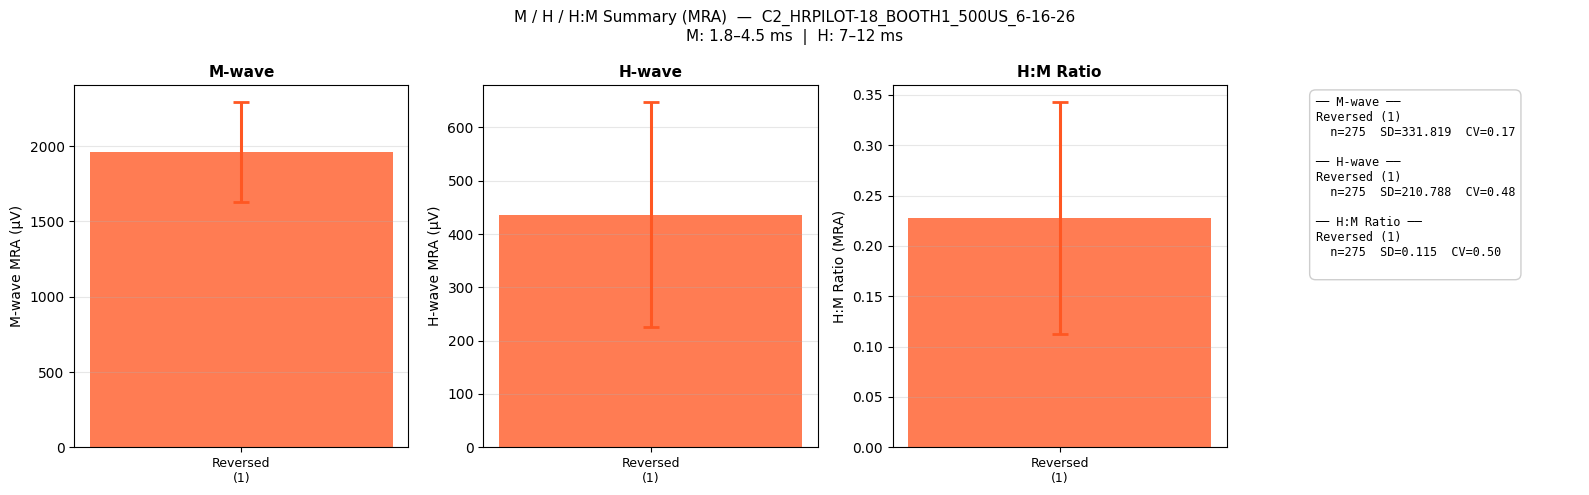

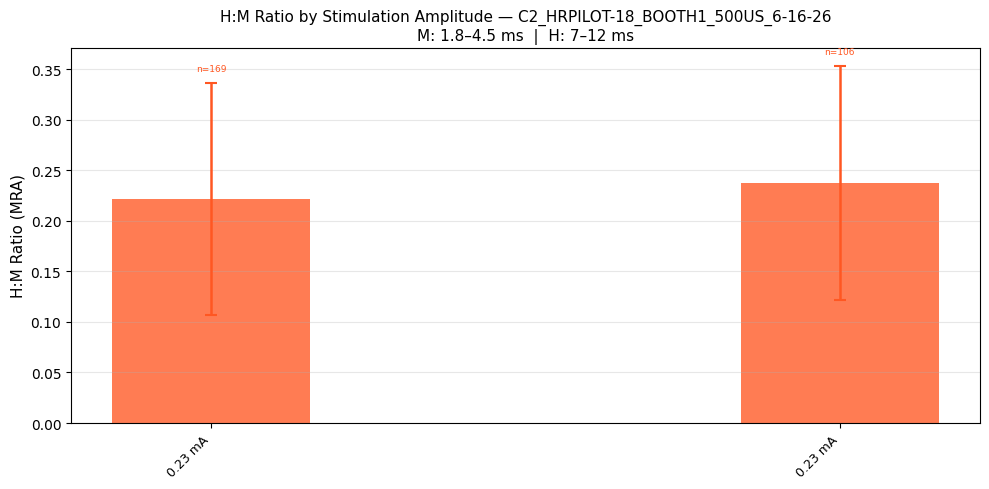

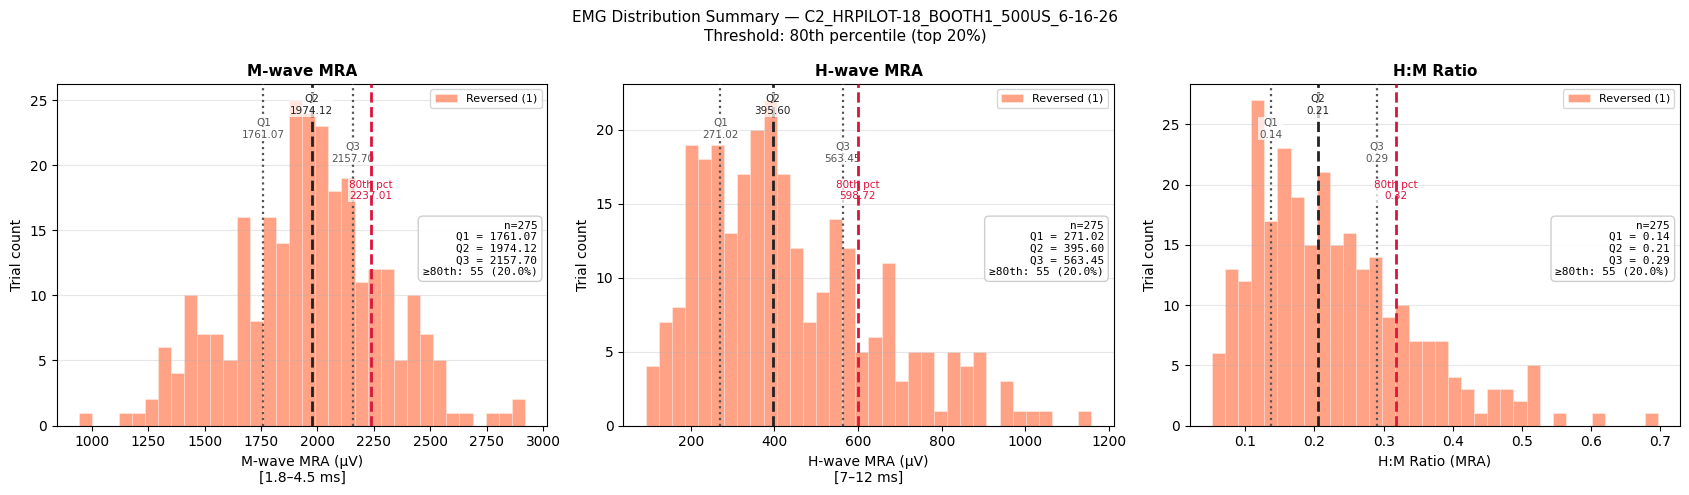

In [32]:
plot_hm_ratio_summary(
    split_trials_by_polarity(analysis_trials), hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 15: SNR Analysis (RMS)

Per-amplitude signal-to-noise ratio using the RMS of the M-wave and H-wave windows against a pre-stim RMS background window.

| Metric | Formula |
|---|---|
| SNR_M | RMS(M-wave) / RMS(pre-stim BG) |
| SNR_H | RMS(H-wave) / RMS(pre-stim BG) |
| SNR_H:M | (RMS_H / RMS_M) / RMS(pre-stim BG) |

Adjust `BG_PRE_MS` to change the background window length.

SNR Analysis — C2_HRPILOT-18_BOOTH1_500US_6-16-26
  M window : 1.8–4.5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                 n      Mean    Median        SD      CV
--------------------------------------------------------------
  SNR_M  (M/BG)      275     4.870     4.486     1.957   0.402
  SNR_H  (H/BG)      275     1.135     0.977     0.670   0.590
  SNR_HM (H:M/BG)    275     0.000     0.000     0.000   0.584


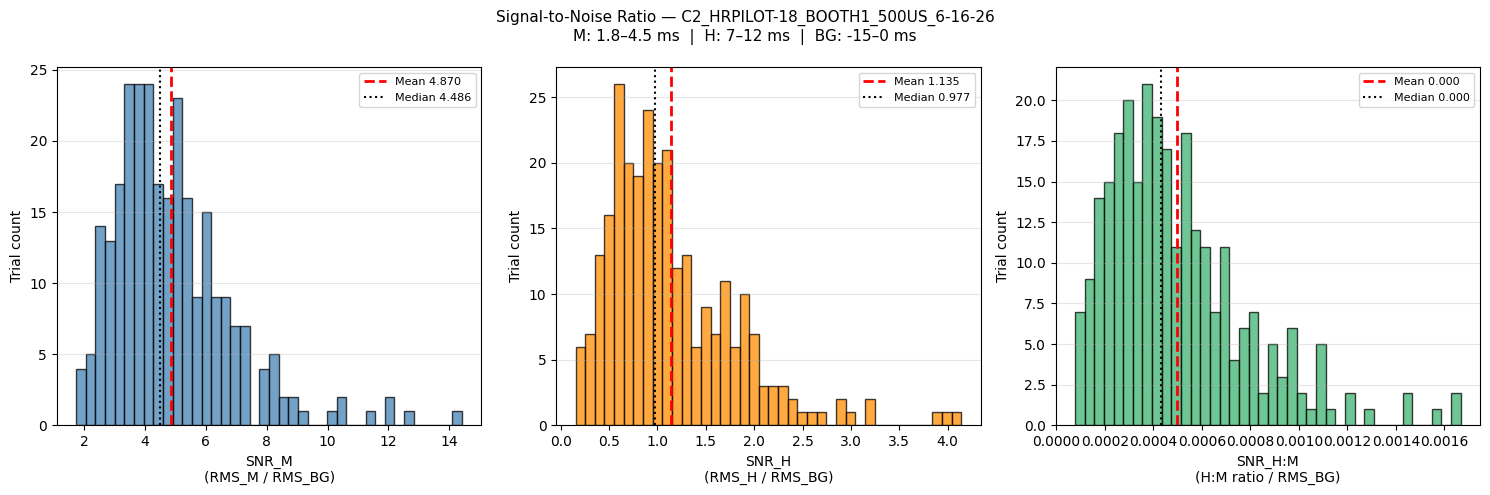

In [33]:
BG_PRE_MS = 15.0  # ms of pre-stim signal used as noise baseline

snr_results = compute_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 16: SNR Analysis (MRA)

Same analysis as Section 15 but uses **Mean Rectified Average** (`mean(|signal|)`) instead of RMS — more robust to asymmetric waveforms.

| Metric | Formula |
|---|---|
| MRA-SNR_M | MRA(M-wave) / MRA(pre-stim BG) |
| MRA-SNR_H | MRA(H-wave) / MRA(pre-stim BG) |
| MRA-SNR_H:M | (MRA_H / MRA_M) / MRA(pre-stim BG) |

MRA-SNR Analysis — C2_HRPILOT-18_BOOTH1_500US_6-16-26
  M window : 1.8–4.5 ms
  H window : 7–12 ms
  BG window: -15–0 ms (pre-stim)

Metric                   n      Mean    Median        SD      CV
----------------------------------------------------------------
  MRA-SNR_M  (M/BG)    275     5.532     5.042     2.390   0.432
  MRA-SNR_H  (H/BG)    275     1.233     1.066     0.793   0.643
  MRA-SNR_HM (H:M/BG)   275     0.001     0.001     0.000   0.647


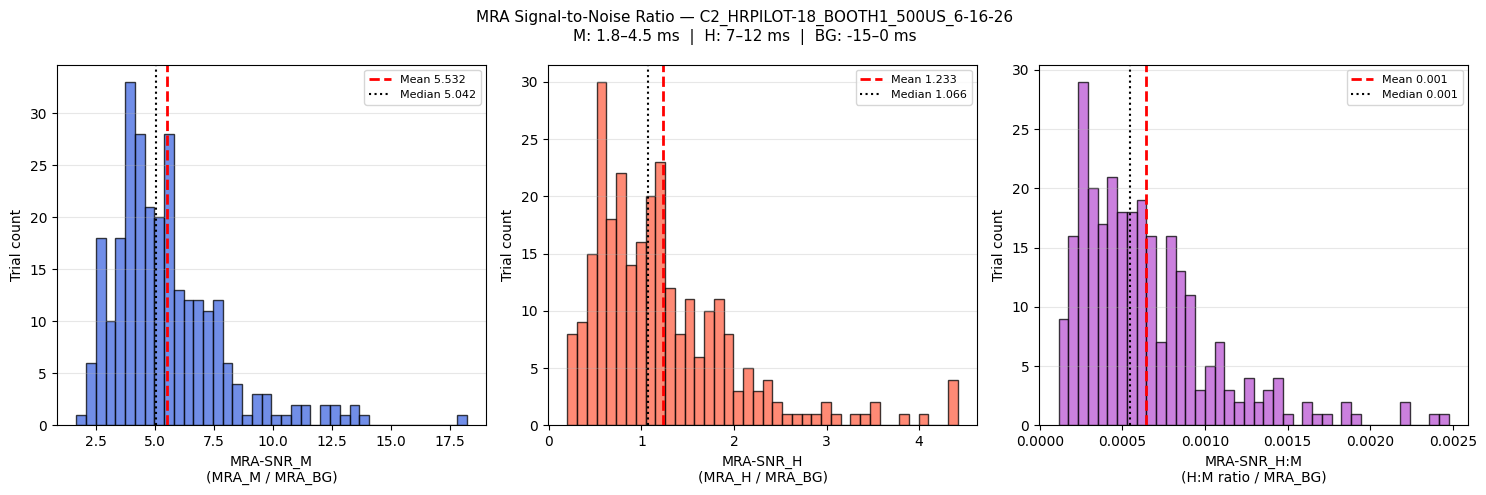

In [34]:
mra_snr_results = compute_mra_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)